## Testing particle.py

## Import and Preprocess

In [1]:
# ================================
# eLoss-only notebook (publication styling)
# ================================
import numpy as np
import sys
import matplotlib.pyplot as plt

# -- modules --
sys.path.append("../code")

from particle import Particle

In [2]:
# Particles
P_b = Particle(family="bottomonia", state="avg")
P_c = Particle(family="charmonia",  state="avg")
roots = 8160.0      # GeV (8.16 TeV); try 5023.0 too
LA_fm = 10.11       # default Pb min-bias; swap from glauber later

P_b.print_summary(roots)
P_c.print_summary(roots)

# Grids
pT = np.linspace(0.0, 30.0, 400)
y  = np.linspace(-5.5, 5.5, 501)

[Particle] Upsilon  M=9.9500 GeV  pp:(p0=6.6, m=2.8, n=13.8), sqrt(s)=8160 GeV
[Particle] JPsi  M=3.4300 GeV  pp:(p0=4.2, m=3.5, n=19.2), sqrt(s)=8160 GeV


In [3]:
# Grids
pT = np.linspace(0.0, 25.0, 101)
y_for_pT = [ -4.0, -2.0, 0.0, +2.0, +4.0 ]
y = np.linspace(-5.0, +5.0, 101)
pT_for_y = [0.0, 2.0, 5.0, 10.0]

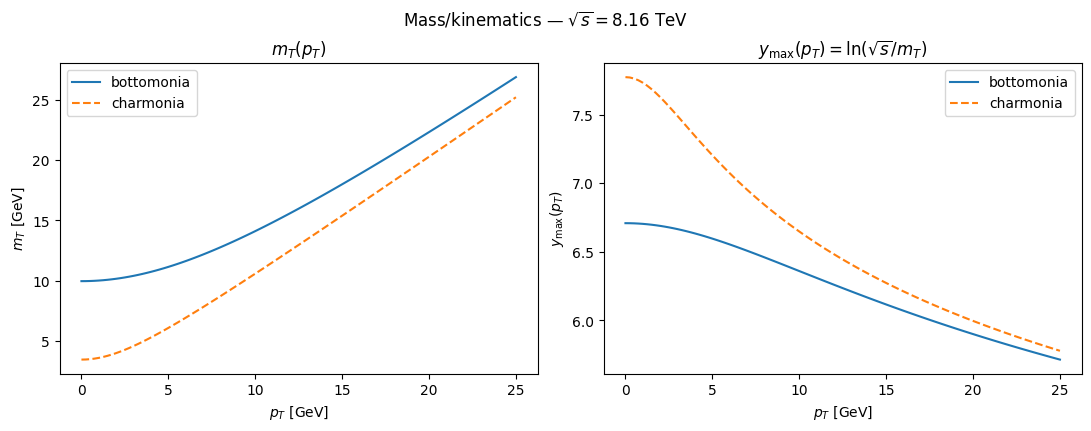

In [4]:
# ---------- Figure A: m_T and y_max ----------
fig, ax = plt.subplots(1, 2, figsize=(10.8, 4.2), constrained_layout=True)

ax[0].plot(pT, P_b.mT(pT), label="bottomonia")
ax[0].plot(pT, P_c.mT(pT), label="charmonia", ls="--")
ax[0].set_xlabel(r"$p_T$ [GeV]")
ax[0].set_ylabel(r"$m_T$ [GeV]")
ax[0].set_title(r"$m_T(p_T)$")
ax[0].legend()

ax[1].plot(pT, Particle.y_max(roots, P_b.mT(pT)), label="bottomonia")
ax[1].plot(pT, Particle.y_max(roots, P_c.mT(pT)), label="charmonia", ls="--")
ax[1].set_xlabel(r"$p_T$ [GeV]")
ax[1].set_ylabel(r"$y_{\max}(p_T)$")
ax[1].set_title(r"$y_{\max}(p_T)=\ln(\sqrt{s}/m_T)$")
ax[1].legend()

fig.suptitle(fr"Mass/kinematics — $\sqrt{{s}}={roots/1000:.2f}$ TeV", fontsize=12)
plt.show()

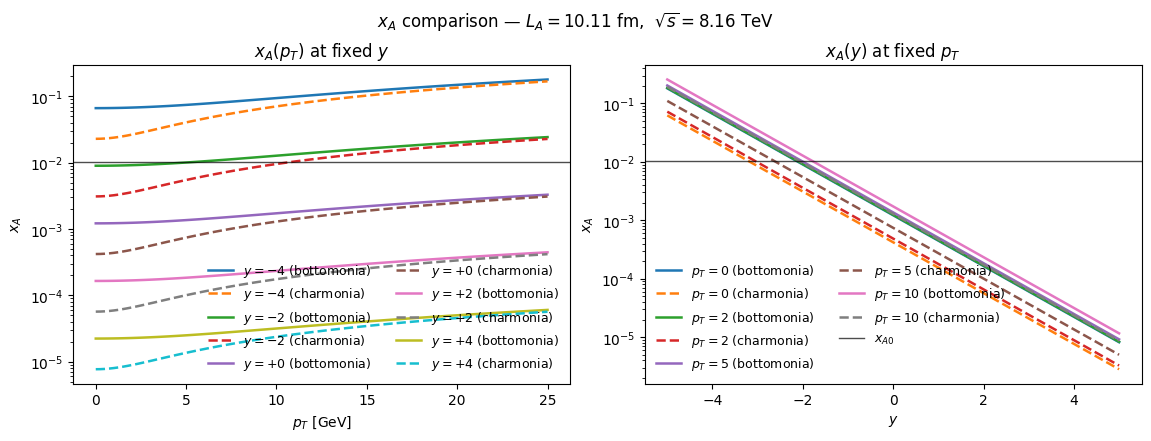

In [6]:
# ---------- Figure B: x_A, cleaned legends ----------
xA0 = Particle.xA0_from_LA(LA_fm)

y_for_pT   = [-4, -2, 0, +2, +4]
pT_for_y   = [0, 2, 5, 10]

fig, ax = plt.subplots(1, 2, figsize=(11.4, 4.3), constrained_layout=True)

# (a) x_A vs pT at fixed y
for yy in y_for_pT:
    m1 = (abs(yy) <= Particle.y_max(roots, P_b.mT(pT)))
    m2 = (abs(yy) <= Particle.y_max(roots, P_c.mT(pT)))
    ax[0].plot(pT[m1], P_b.xA(yy, pT[m1], roots), lw=1.8, label=fr"$y={yy:+d}$ (bottomonia)")
    ax[0].plot(pT[m2], P_c.xA(yy, pT[m2], roots), lw=1.8, ls="--", label=fr"$y={yy:+d}$ (charmonia)")
ax[0].axhline(xA0, color="k", lw=1.0, alpha=0.7)
ax[0].set_yscale("log")
ax[0].set_xlabel(r"$p_T$ [GeV]"); ax[0].set_ylabel(r"$x_A$")
ax[0].set_title(r"$x_A(p_T)$ at fixed $y$")
ax[0].legend(ncol=2, fontsize=9, frameon=False)

# (b) x_A vs y at fixed pT; also min(x_A, x_A0)
for p in pT_for_y:
    m1 = (abs(y) <= Particle.y_max(roots, P_b.mT(p)))
    m2 = (abs(y) <= Particle.y_max(roots, P_c.mT(p)))
    xa1 = np.where(m1, P_b.xA(y, p, roots), np.nan)
    xa2 = np.where(m2, P_c.xA(y, p, roots), np.nan)
    ax[1].plot(y, xa1, lw=1.8, label=fr"$p_T={p:g}$ (bottomonia)")
    ax[1].plot(y, xa2, lw=1.8, ls="--", label=fr"$p_T={p:g}$ (charmonia)")
ax[1].axhline(xA0, color="k", lw=1.0, alpha=0.7, label=r"$x_{A0}$")
ax[1].set_yscale("log")
ax[1].set_xlabel(r"$y$"); ax[1].set_ylabel(r"$x_A$")
ax[1].set_title(r"$x_A(y)$ at fixed $p_T$")
ax[1].legend(ncol=2, fontsize=9, frameon=False)

fig.suptitle(fr"$x_A$ comparison — $L_A={LA_fm}$ fm,  $\sqrt{{s}}={roots/1000:.2f}$ TeV", fontsize=12)
plt.show()

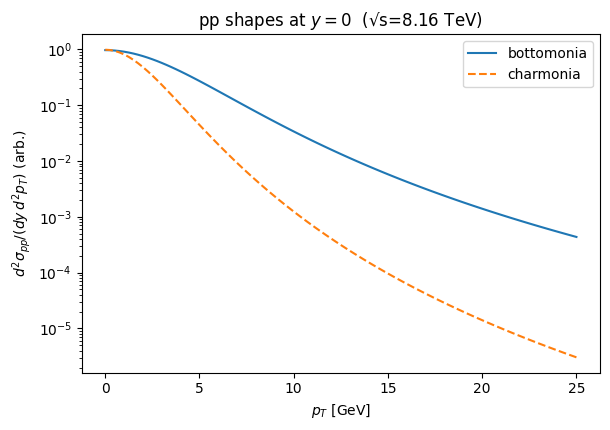

In [8]:
## quick pp spectra line at y=0 for a sanity check
s_b = P_b.d2sigma_pp(0.0, pT, roots)
s_c = P_c.d2sigma_pp(0.0, pT, roots)
plt.figure(figsize=(6.2,4.4))
plt.plot(pT, s_b, label="bottomonia")
plt.plot(pT, s_c, label="charmonia", ls="--")
plt.yscale("log"); plt.xlabel(r"$p_T$ [GeV]"); plt.ylabel(r"$d^2\sigma_{pp}/(dy\,d^2p_T)$ (arb.)")
plt.title(fr"pp shapes at $y=0$  (√s={roots/1000:.2f} TeV)")
plt.legend(); plt.tight_layout(); plt.show()

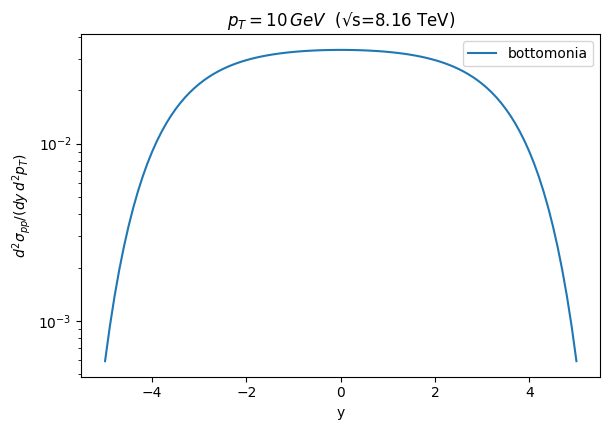

In [16]:
## quick pp spectra line at pT=10 for a sanity check
s_b = P_b.d2sigma_pp(y, 10.0, roots)
plt.figure(figsize=(6.2,4.4))
plt.plot(y, s_b, label="bottomonia")
plt.yscale("log")
plt.xlabel("y"); plt.ylabel(r"$d^2\sigma_{pp}/(dy\,d^2p_T)$")
plt.title(fr"$p_T=10 \, GeV$  (√s={roots/1000:.2f} TeV)")
plt.legend(); plt.tight_layout(); plt.show()

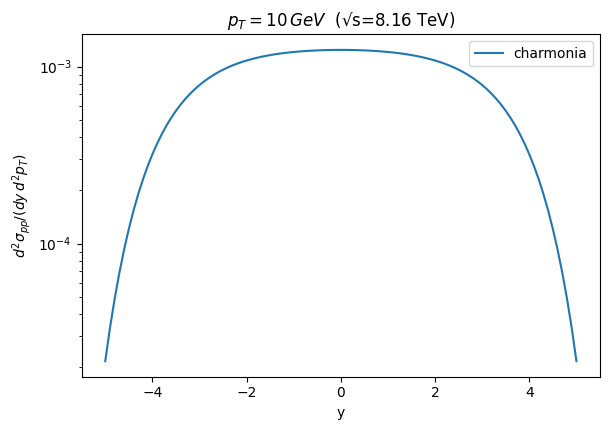

In [15]:
## quick pp spectra line at pT=10 for a sanity check
s_c = P_c.d2sigma_pp(y, 10.0, roots)
plt.figure(figsize=(6.2,4.4))
plt.plot(y, s_c, label="charmonia")
plt.yscale("log")
plt.xlabel("y"); plt.ylabel(r"$d^2\sigma_{pp}/(dy\,d^2p_T)$")
plt.title(fr"$p_T=10 \, GeV$  (√s={roots/1000:.2f} TeV)")
plt.legend(); plt.tight_layout(); plt.show()

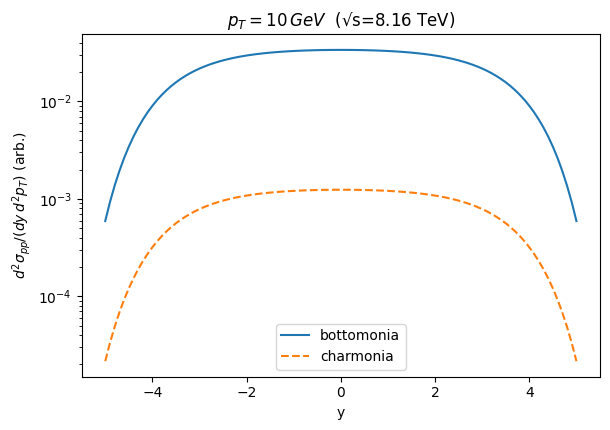

In [12]:
## quick pp spectra line at pT=10 for a sanity check
s_b = P_b.d2sigma_pp(y, 10.0, roots)
s_c = P_c.d2sigma_pp(y, 10.0, roots)
plt.figure(figsize=(6.2,4.4))
plt.plot(y, s_b, label="bottomonia")
plt.plot(y, s_c, label="charmonia", ls="--")
plt.yscale("log")
plt.xlabel("y"); plt.ylabel(r"$d^2\sigma_{pp}/(dy\,d^2p_T)$ (arb.)")
plt.title(fr"$p_T=10 \, GeV$  (√s={roots/1000:.2f} TeV)")
plt.legend(); plt.tight_layout(); plt.show()